# Python Portfolio 01 — E-commerce Customer & Sales Analysis

**Executed, reproducible notebook** · pandas data cleaning · UK e-commerce KPIs · RFM segmentation · cohort retention

> All data and commercial results are synthetic. The observation period ends **31 August 2026**; 2026 is partial-year. Open this notebook in the repository folder next to the four `raw_*.csv` files to re-run it.

In [1]:
"""Reproducible Python Portfolio 01 analysis on invented ecommerce data."""

'Reproducible Python Portfolio 01 analysis on invented ecommerce data.'

## 1. Imports and data loading

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

BASE = Path(__file__).resolve().parent if '__file__' in globals() else Path.cwd()
customers_raw = pd.read_csv(BASE/'raw_customers.csv')
products = pd.read_csv(BASE/'raw_products.csv')
orders_raw = pd.read_csv(BASE/'raw_orders.csv')
items_raw = pd.read_csv(BASE/'raw_order_items.csv')
SNAPSHOT = pd.Timestamp('2026-08-31')
print('Raw data:',len(customers_raw),'customers,',len(orders_raw),'orders,',len(items_raw),'order lines')

Raw data: 260 customers, 2194 orders, 3481 order lines


## 2. Data-quality audit and cleaning

In [3]:
issues={}
issues['duplicate_order_ids'] = int(orders_raw.duplicated('order_id').sum())
issues['duplicate_line_ids'] = int(items_raw.duplicated('order_item_id').sum())
issues['missing_customer_region'] = int(customers_raw.region.isna().sum())

customers=customers_raw.copy()
customers['region']=customers.region.fillna('Unknown').astype(str).str.strip().str.title()
customers['signup_date']=pd.to_datetime(customers.signup_date,errors='coerce')

orders=orders_raw.drop_duplicates('order_id').copy()
orders['order_date']=pd.to_datetime(orders.order_date,errors='coerce')
orders['status']=orders.status.astype(str).str.strip().str.title()
issues['invalid_order_dates']=int(orders.order_date.isna().sum())
issues['invalid_order_status']=int((~orders.status.isin(['Completed','Cancelled','Returned'])).sum())
orders=orders.dropna(subset=['order_date'])
orders=orders[orders.status.isin(['Completed','Cancelled','Returned'])]

items=items_raw.drop_duplicates('order_item_id').copy()
issues['invalid_item_quantity']=int((items.quantity<=0).sum())
issues['invalid_item_price_or_cost']=int(((items.unit_price_gbp<=0)|(items.unit_cost_gbp<0)).sum())
issues['invalid_discounts']=int(((items.discount_pct<0)|(items.discount_pct>=1)).sum())
items=items[(items.quantity>0)&(items.unit_price_gbp>0)&(items.unit_cost_gbp>=0)&
            (items.discount_pct>=0)&(items.discount_pct<1)]
issues['unmatched_product_ids']=int((~items.product_id.isin(products.product_id)).sum())
issues['unmatched_order_ids']=int((~items.order_id.isin(orders.order_id)).sum())
items=items[items.product_id.isin(products.product_id)&items.order_id.isin(orders.order_id)].copy()
issues['unmatched_customer_ids']=int((~orders.customer_id.isin(customers.customer_id)).sum())
orders=orders[orders.customer_id.isin(customers.customer_id)].copy()
items=items[items.order_id.isin(orders.order_id)].copy()
audit=pd.DataFrame([{'check':k,'rows_affected':v} for k,v in issues.items()])
audit.to_csv(BASE/'result_data_quality_audit.csv',index=False)
print('\nData quality audit:')
print(audit.to_string(index=False))


Data quality audit:
                     check  rows_affected
       duplicate_order_ids              1
        duplicate_line_ids              3
   missing_customer_region             12
       invalid_order_dates              1
      invalid_order_status              0
     invalid_item_quantity              1
invalid_item_price_or_cost              1
         invalid_discounts              1
     unmatched_product_ids              1
       unmatched_order_ids              1
    unmatched_customer_ids              0


## 3. Join the model and define recognised revenue

In [4]:
sales=(items.merge(orders,on='order_id',how='inner',validate='many_to_one')
            .merge(products.drop(columns=['unit_cost_gbp']),on='product_id',how='inner',validate='many_to_one')
            .merge(customers[['customer_id','region']],on='customer_id',how='inner',validate='many_to_one'))
sales['net_revenue_gbp']=(sales.quantity*sales.unit_price_gbp*(1-sales.discount_pct)).round(2)
sales['cogs_gbp']=sales.quantity*sales.unit_cost_gbp
sales['gross_profit_gbp']=(sales.net_revenue_gbp-sales.cogs_gbp).round(2)
completed=sales[sales.status.eq('Completed')].copy()
completed['year']=completed.order_date.dt.year
completed['month']=completed.order_date.dt.strftime('%Y-%m')
completed['month_number']=completed.order_date.dt.month
print(f'\nClean order lines: {len(sales)}; completed order lines: {len(completed)}')


Clean order lines: 3473; completed order lines: 2894


## 4. Business KPIs and like-for-like YTD comparison

In [5]:
def summarize(frame):
    g=frame.groupby('year').agg(completed_orders=('order_id','nunique'),
          active_customers=('customer_id','nunique'),net_revenue_gbp=('net_revenue_gbp','sum'),
          gross_profit_gbp=('gross_profit_gbp','sum')).reset_index()
    g['gross_margin_pct']=(100*g.gross_profit_gbp/g.net_revenue_gbp).round(2)
    g['avg_order_value_gbp']=(g.net_revenue_gbp/g.completed_orders).round(2)
    g[['net_revenue_gbp','gross_profit_gbp']]=g[['net_revenue_gbp','gross_profit_gbp']].round(2)
    return g
annual=summarize(completed)
ytd=summarize(completed[completed.month_number<=8])
annual.to_csv(BASE/'result_annual_kpis.csv',index=False)
ytd.to_csv(BASE/'result_jan_aug_comparison.csv',index=False)
monthly=completed.groupby('month',as_index=False).agg(net_revenue_gbp=('net_revenue_gbp','sum'),
                    gross_profit_gbp=('gross_profit_gbp','sum'),orders=('order_id','nunique'))
monthly[['net_revenue_gbp','gross_profit_gbp']]=monthly[['net_revenue_gbp','gross_profit_gbp']].round(2)
monthly.to_csv(BASE/'result_monthly_sales.csv',index=False)
print('\nAnnual KPIs (2026 covers Jan-Aug only):')
print(annual.to_string(index=False))
print('\nComparable Jan-Aug KPIs:')
print(ytd.to_string(index=False))


Annual KPIs (2026 covers Jan-Aug only):
 year  completed_orders  active_customers  net_revenue_gbp  gross_profit_gbp  gross_margin_pct  avg_order_value_gbp
 2024               540               133        207202.75          64342.75             31.05               383.71
 2025               718               195        274915.90          86228.90             31.37               382.89
 2026               590               225        237060.05          74447.05             31.40               401.80

Comparable Jan-Aug KPIs:
 year  completed_orders  active_customers  net_revenue_gbp  gross_profit_gbp  gross_margin_pct  avg_order_value_gbp
 2024               362               115        136475.25          43159.25             31.62               377.00
 2025               487               173        186125.70          58643.70             31.51               382.19
 2026               590               225        237060.05          74447.05             31.40               401.80


**Reporting note:** 2026 contains January–August only; compare `ytd` results across all three years.

## 5. Commercial performance by product category and customer region

In [6]:
category=completed.groupby('category',as_index=False).agg(
    net_revenue_gbp=('net_revenue_gbp','sum'),gross_profit_gbp=('gross_profit_gbp','sum'),
    orders=('order_id','nunique')).sort_values('net_revenue_gbp',ascending=False)
category['gross_margin_pct']=(100*category.gross_profit_gbp/category.net_revenue_gbp).round(2)
category[['net_revenue_gbp','gross_profit_gbp']]=category[['net_revenue_gbp','gross_profit_gbp']].round(2)
category.to_csv(BASE/'result_category_performance.csv',index=False)
region=completed.groupby('region',as_index=False).agg(
    net_revenue_gbp=('net_revenue_gbp','sum'),orders=('order_id','nunique'),
    customers=('customer_id','nunique')).sort_values('net_revenue_gbp',ascending=False)
region.net_revenue_gbp=region.net_revenue_gbp.round(2)
region.to_csv(BASE/'result_region_performance.csv',index=False)

## 6. Customer RFM-style segmentation (descriptive, not predictive)

In [7]:
customer_rfm=completed.groupby('customer_id').agg(last_purchase=('order_date','max'),
   frequency=('order_id','nunique'),monetary_gbp=('net_revenue_gbp','sum')).reset_index()
customer_rfm['recency_days']=(SNAPSHOT-customer_rfm.last_purchase).dt.days
customer_rfm['segment']=np.select([
    (customer_rfm.recency_days<=90)&(customer_rfm.frequency>=6),
    (customer_rfm.recency_days<=120)&(customer_rfm.frequency>=3),
    (customer_rfm.recency_days>180)&(customer_rfm.frequency>=3),
    (customer_rfm.recency_days<=180)&(customer_rfm.frequency>=2),
],['Champions','Loyal','At Risk','Developing'],default='Occasional')
customer_rfm['last_purchase']=customer_rfm.last_purchase.dt.strftime('%Y-%m-%d')
customer_rfm.monetary_gbp=customer_rfm.monetary_gbp.round(2)
customer_rfm.sort_values('monetary_gbp',ascending=False).to_csv(BASE/'result_customer_rfm.csv',index=False)
segment_summary=customer_rfm.groupby('segment',as_index=False).agg(customers=('customer_id','count'),
    revenue_gbp=('monetary_gbp','sum')).sort_values('customers',ascending=False)
segment_summary.revenue_gbp=segment_summary.revenue_gbp.round(2)
segment_summary.to_csv(BASE/'result_customer_segments.csv',index=False)
print('\nCustomer segments:')
print(segment_summary.to_string(index=False))


Customer segments:
   segment  customers  revenue_gbp
 Champions         98    416700.05
     Loyal         59    134961.90
Developing         39     84562.05
Occasional         23      9430.60
   At Risk         21     73524.10


## 7. Monthly customer cohort retention, months 0-6

In [8]:
customer_months=completed[['customer_id','month']].drop_duplicates().copy()
customer_months['purchase_month']=pd.to_datetime(customer_months.month+'-01')
first=customer_months.groupby('customer_id').purchase_month.min().rename('cohort_month')
customer_months=customer_months.join(first,on='customer_id')
customer_months['months_since_first']=(
    (customer_months.purchase_month.dt.year-customer_months.cohort_month.dt.year)*12+
    customer_months.purchase_month.dt.month-customer_months.cohort_month.dt.month)
counts=(customer_months[customer_months.months_since_first<=6]
        .groupby(['cohort_month','months_since_first']).customer_id.nunique().unstack())
counts=counts.reindex(columns=range(7))
cohort_sizes=counts[0]
retention=counts.div(cohort_sizes,axis=0).mul(100).round(1)
retention.index=retention.index.strftime('%Y-%m')
retention.index.name='cohort_month'
retention.columns=[f'month_{i}_pct' for i in range(7)]
retention.reset_index().to_csv(BASE/'result_cohort_retention.csv',index=False)
print('\nCohorts calculated:',len(retention),'(cohorts without enough elapsed months have blank future periods).')


Cohorts calculated: 32 (cohorts without enough elapsed months have blank future periods).


**Interpretation:** Cohort month uses first observed purchase. Missing future cells are not zero-retention observations.

## 8. Save evidence charts

In [9]:
plt.figure(figsize=(10,5))
for yr,frame in monthly.assign(year=lambda d:d.month.str[:4],month_num=lambda d:d.month.str[5:].astype(int)).groupby('year'):
    plt.plot(frame.month_num,frame.net_revenue_gbp,marker='o',label=yr)
plt.xticks(range(1,13))
plt.xlabel('Order month')
plt.ylabel('Net completed-order revenue (£)')
plt.title('Monthly net sales: 2024–2026 (2026 through August)')
plt.legend(title='Year')
plt.grid(alpha=.2)
plt.tight_layout()
plt.savefig(BASE/'chart_monthly_revenue.png',dpi=170)
plt.close()

shown=retention.tail(12)
fig,ax=plt.subplots(figsize=(9,7))
arr=shown.to_numpy(dtype=float)
im=ax.imshow(arr,aspect='auto',vmin=0,vmax=100,cmap='Blues')
ax.set_yticks(range(len(shown)),shown.index)
ax.set_xticks(range(7),[str(i) for i in range(7)])
ax.set_xlabel('Months since first completed order')
ax.set_title('Monthly customer retention: last 12 acquisition cohorts')
fig.colorbar(im,ax=ax,label='Retention (%)')
plt.tight_layout()
plt.savefig(BASE/'chart_cohort_retention.png',dpi=170)
plt.close()

fig,ax=plt.subplots(figsize=(8,4.5))
ax.bar(segment_summary.segment,segment_summary.customers)
ax.set_title('Customers by descriptive RFM segment')
ax.set_ylabel('Customers')
ax.tick_params(axis='x',rotation=15)
plt.tight_layout()
plt.savefig(BASE/'chart_customer_segments.png',dpi=170)
plt.close()

## 9. Automated reconciliation and limitations

In [10]:
assert annual.completed_orders.sum()==completed.order_id.nunique()
assert len(annual)==3 and len(ytd)==3
assert (customer_rfm.recency_days>=0).all()
assert (retention.iloc[:,0]==100).all()
assert int(audit.loc[audit.check=='duplicate_line_ids','rows_affected'].iloc[0])==3
assert all((annual.net_revenue_gbp>0)&(annual.gross_margin_pct>0))
print('\nValidation passed: unique orders, first-month cohort retention, deduplication and nonnegative recency.')
print('Important: Jan-Aug 2026 is partial-year; use result_jan_aug_comparison.csv for year-over-year comparisons.')


Validation passed: unique orders, first-month cohort retention, deduplication and nonnegative recency.
Important: Jan-Aug 2026 is partial-year; use result_jan_aug_comparison.csv for year-over-year comparisons.


## Visual evidence

The charts below are programmatically regenerated in section 8.

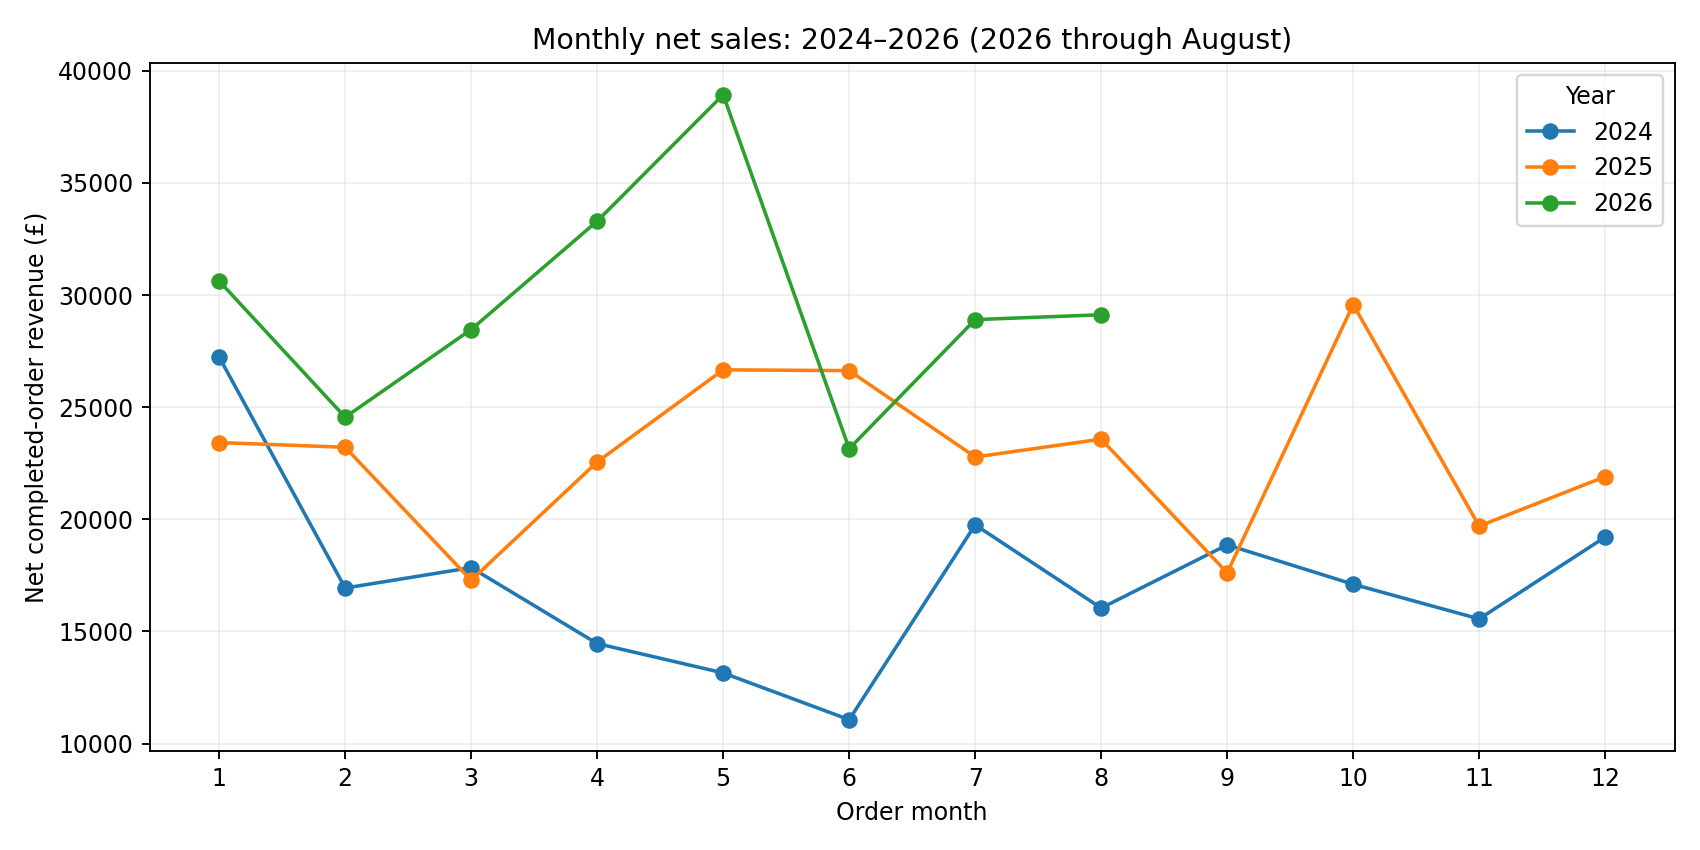

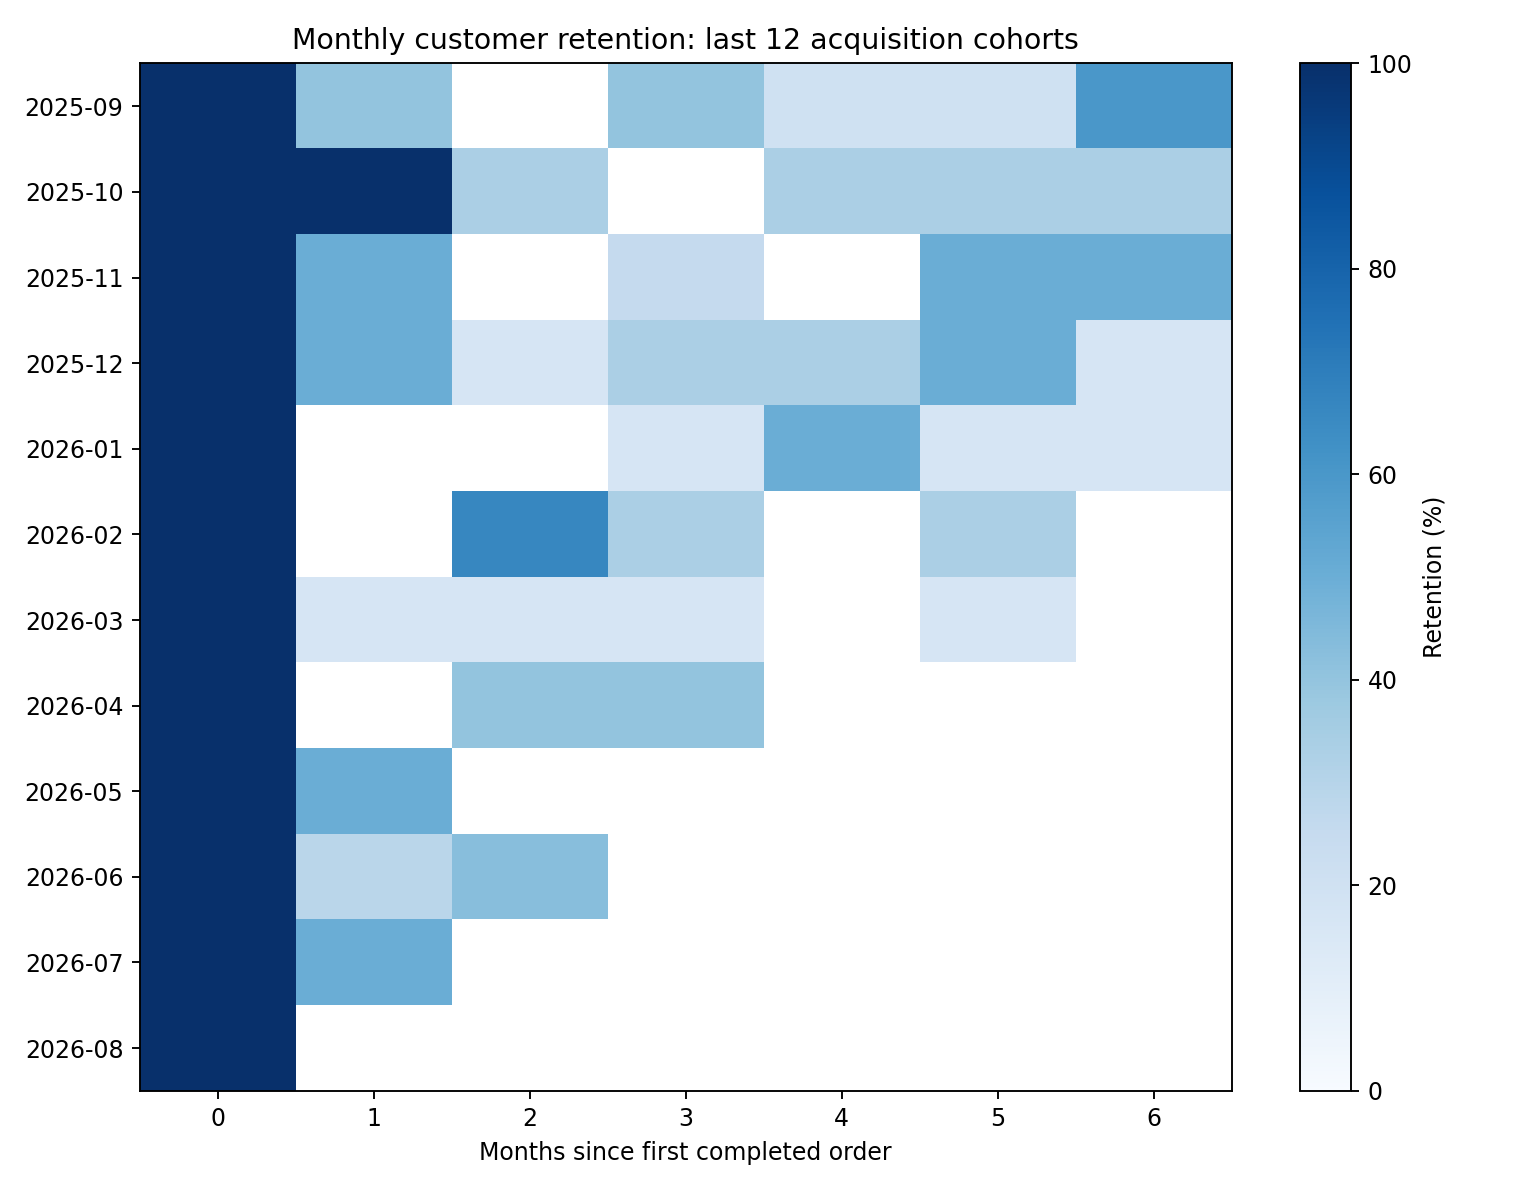

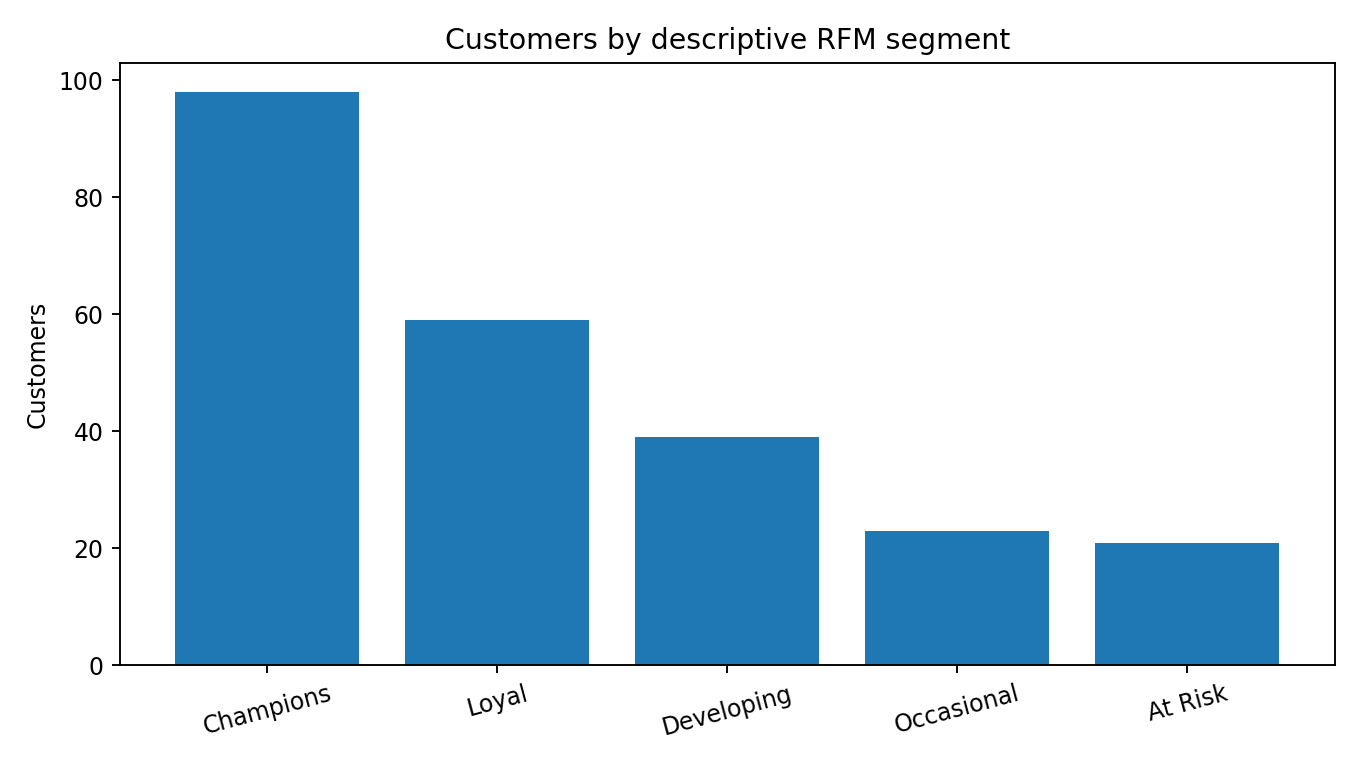

In [11]:
from IPython.display import display, Image
for chart in ['chart_monthly_revenue.png','chart_cohort_retention.png','chart_customer_segments.png']:
    display(Image(filename=str(BASE/chart)))

## Closing interpretation

The generated sample illustrates rising January–August net sales, substantial Electronics revenue concentration and identifiable recent/frequent customer groups. The descriptive cohorts and segments are not forecasts or causal evidence. Consult the README and Data Dictionary for KPI definitions, exclusions and limitations.